## Stage 0 — World and LLM Setup

Identical to `runner.ipynb`: loads the PR2-apartment world, scopes grounding to physical `Body` instances.

In [1]:
from uniworld import load_pr2_apartment_world
from semantic_digital_twin.world_description.world_entity import Body

world, robot_view, context = load_pr2_apartment_world()
context.evaluate_conditions = False

symbol_type = Body
# print("World loaded:", type(world).__name__)
# print("Robot:", robot_view)

`polytope` failed to import `cvxopt.glpk`.
will use `scipy.optimize.linprog`
Unknown attribute "type" in /robot[@name='pr2']/link[@name='base_laser_link']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='wide_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='narrow_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='laser_tilt_link']
Unknown tag "material" in /robot[@name='pr2']/link[@name='l_force_torque_link']/collision[1]
Unknown tag "material" in /robot[@name='apartment']/link[@name='coffe_machine']/collision[1]


In [2]:
from dotenv import load_dotenv
from llmr.reasoning.llm_provider import make_llm, LLMProvider

load_dotenv("../.env")

llm = make_llm(LLMProvider.OPENAI, model="gpt-4o-mini", temperature=0.0)
print("LLM ready:", getattr(llm, "model_name", llm))

LLM ready: gpt-4o-mini


In [3]:
# ROS setup
import rclpy
from semantic_digital_twin.adapters.ros.tf_publisher import TFPublisher
from semantic_digital_twin.adapters.ros.visualization.viz_marker import VizMarkerPublisher
rclpy.init()
_ros_node = rclpy.create_node('semantic_digital_twin')
import threading
_ros_thread = threading.Thread(target=rclpy.spin, args=(_ros_node,), daemon=True)
_ros_thread.start()

In [4]:
_tf_publisher = TFPublisher(_world=world, node=_ros_node)
_viz_publisher = VizMarkerPublisher(_world=world, node=_ros_node)
print("ROS2 publishers started")

ROS2 publishers started


## Stage 1 — Graph Bootstrap via `BuildOrchestrator`

`BuildOrchestrator.with_default_builders()` creates a shared repository and wires all
registered hypothesis builders automatically — no manual `BuilderRegistry` construction.
The call returns an orchestrator whose `.graph` property is the shared `HypothesisGraph`.

In [5]:
from llmr.hypotheses import (
    # graph core
    HypothesisGraph,
    # entity types
    FrameClaim, RoleClaim,
    PlanClaim, PhaseClaim,
    Instruction, Action, ReasonerRun,
    SlotEvidence, GroundingEvidence,
    # orchestrator
    BuildOrchestrator,
    # views
    FlanaganGraphView, FrameNetGraphView,
    FLANAGAN_REASONER_NAME, FRAMENET_REASONER_NAME,
    # metadata enums
    ClaimStatus, GroundingState,
    HypothesisMeta,
)
from llmr.hypotheses.entities.base import (
    ClaimHypothesis, AnchorHypothesis, EvidenceHypothesis, ProjectedClaimHypothesis
)
from llmr.hypotheses.adapters import to_dot

# --- bootstrap with BuildOrchestrator ---
orchestrator = BuildOrchestrator.with_default_builders()
graph = orchestrator.graph

print(f"Builders registered:")
for b in orchestrator.registry.builders:
    print(f"  {type(b).__name__}")

# family-specific views over the same graph
framenet = FrameNetGraphView(graph=graph)
flanagan = FlanaganGraphView(graph=graph)

print("\nGraph + views ready.")

Builders registered:
  FrameNetBuilder
  FlanaganBuilder

Graph + views ready.


## Stage 2 — Run Combined Inference

Both reasoners populate the same `HypothesisGraph` in a single `LLMBackend` evaluation.

In [6]:
from krrood.entity_query_language.query.match import Match
from llmr.backend import LLMBackend
from llmr.reasoning.framenet_reasoner import FrameNetReasoner
from llmr.reasoning.flanagan_reasoner import FlanaganReasoner
from pycram.datastructures.grasp import GraspDescription
from pycram.robot_plans.actions.core.pick_up import PickUpAction

INSTRUCTION = "pick up the milk from the table"


def fresh_pickup_match():
    return Match(PickUpAction)(
        object_designator=...,
        arm=...,
        grasp_description=Match(GraspDescription)(
            approach_direction=...,
            vertical_alignment=...,
            manipulator=...,
        ),
    )


def run_instruction(instruction: str, graph: HypothesisGraph, orchestrator):
    backend = LLMBackend(
        llm=llm,
        symbol_type=symbol_type,
        instruction=instruction,
        strict_required=True,
        reasoners=[FrameNetReasoner(llm=llm), FlanaganReasoner(llm=llm)],
        sg_model_orchestrator=orchestrator,
    )
    action = next(iter(backend.evaluate(fresh_pickup_match())))
    return action, backend


action, backend = run_instruction(INSTRUCTION, graph, orchestrator)

print("Resolved action:", type(action).__name__)
print("Resolved object:", action.object_designator)
print("Resolved arm:", action.arm)
print(f"Graph: {len(graph)} entities")
print(f"FrameNet claims: {len(framenet.claims())}")
print(f"Flanagan claims: {len(flanagan.claims())}")

Resolved action: PickUpAction
Resolved object: Body(name=PrefixedName('None/milk.stl'), id=UUID('0107e297-9d90-41a8-a8ee-985377d732bf'), index=219)
Resolved arm: RIGHT
Graph: 62 entities
FrameNet claims: 12
Flanagan claims: 44


## Stage 3 — MRO-Aware Domain Queries

`graph.domain(cls)` uses a per-class index built at insert time via MRO traversal.
Every concrete entity is bucketed under its own type **and** all `Hypothesis` superclasses.

This means querying `domain(ClaimHypothesis)` returns every `FrameClaim`,
`RoleClaim`, `PlanClaim`, and `PhaseClaim` in O(1) — no `isinstance` scan.

```
Hypothesis (abstract)
├── AnchorHypothesis (abstract) → Instruction, Action, ReasonerRun
├── ClaimHypothesis (abstract)
│   └── ProjectedClaimHypothesis (abstract)
│       ├── FrameClaim, RoleClaim
│       └── PlanClaim, PhaseClaim, PreconditionClaim, ...
└── EvidenceHypothesis (abstract) → SlotEvidence, GroundingEvidence
```

In [ ]:
# 3a — concrete-type domain
frames = graph.domain(FrameClaim)
roles = graph.domain(RoleClaim)
plans = graph.domain(PlanClaim)
phases = graph.domain(PhaseClaim)

print("Concrete domains:")
print(f"  FrameClaim  : {len(frames)}")
print(f"  RoleClaim   : {len(roles)}")
print(f"  PlanClaim   : {len(plans)}")
print(f"  PhaseClaim  : {len(phases)}")

# 3b — abstract-superclass domain (MRO-aware)
all_claims = graph.domain(ClaimHypothesis)            # all claim entities
all_evidence = graph.domain(EvidenceHypothesis)       # SlotEvidence + GroundingEvidence
all_context = graph.domain(AnchorHypothesis)          # Instruction + Action + ReasonerRun
reasoner_claims = graph.domain(ProjectedClaimHypothesis)

print("\nAbstract superclass domains (MRO-aware):")
print(f"  ClaimHypothesis          : {len(all_claims)} entities")
print(f"  ProjectedClaimHypothesis : {len(reasoner_claims)} entities")
print(f"  EvidenceHypothesis       : {len(all_evidence)} entities")
print(f"  AnchorHypothesis         : {len(all_context)} entities")
print(f"  Total accounted  : {len(all_claims) + len(all_evidence) + len(all_context)} / {len(graph)} entities")

# 3c — sibling branches are disjoint
claim_ids = {n.id for n in all_claims}
context_ids = {n.id for n in all_context}
evidence_ids = {n.id for n in all_evidence}
assert claim_ids.isdisjoint(context_ids) and claim_ids.isdisjoint(evidence_ids)
print("\nSanity: claim / context / evidence domains are pairwise disjoint ✓")

In [ ]:
# 3d — filter over abstract domain
grounded_claims = [
    n for n in graph.domain(ClaimHypothesis)
    if n.meta.grounding == GroundingState.SYMBOL_GROUNDED
]

supported_claims = [
    n for n in graph.domain(ClaimHypothesis)
    if n.meta.status == ClaimStatus.SUPPORTED
]

framenet_hypotheses = [
    n for n in graph.domain(ClaimHypothesis)
    if n.meta.source_reasoner == FRAMENET_REASONER_NAME
]

flanagan_hypotheses = [
    n for n in graph.domain(ClaimHypothesis)
    if n.meta.source_reasoner == FLANAGAN_REASONER_NAME
]

print("Filtered domain queries over ClaimHypothesis:")
print(f"  symbol-grounded claims : {len(grounded_claims)}")
print(f"  supported claims       : {len(supported_claims)}")
print(f"  framenet claims        : {len(framenet_hypotheses)}")
print(f"  flanagan claims        : {len(flanagan_hypotheses)}")

# 3e — typed domain per reasoner run
run_nodes = graph.reasoner_runs
print(f"\nReasoner runs:")
for r in run_nodes:
    print(f"  {r.reasoner_name:25s}  run_id={r.meta.short_run_id}")

## Stage 4 — `get_instances_of_type` as EQL Instance Provider

`graph.get_instances_of_type(cls)` returns a list of entities of the given type.
This makes `HypothesisGraph` a drop-in domain source for EQL `variable()` queries.

```python
role = variable(RoleClaim,
                domain=graph.get_instances_of_type(RoleClaim))
```

The instance provider is backed by the MRO index, so it is O(1) regardless of graph size.

In [ ]:
from krrood.entity_query_language.factories import an, entity, variable

# --- declare EQL variables backed by the instance provider ---
frame_var  = variable(FrameClaim, domain=graph.get_instances_of_type(FrameClaim))
role_var   = variable(RoleClaim,  domain=graph.get_instances_of_type(RoleClaim))
plan_var   = variable(PlanClaim,  domain=graph.get_instances_of_type(PlanClaim))
phase_var  = variable(PhaseClaim, domain=graph.get_instances_of_type(PhaseClaim))

# --- EQL query 1: frame for the exact instruction ---
q_frame = an(entity(frame_var).where(frame_var.instruction_text == INSTRUCTION))
frame_results = list(q_frame.evaluate())
print("Query 1 — frame for instruction:")
for f in frame_results:
    print(f"  frame={f.frame!r}  lexical_unit={f.lexical_unit!r}  label={f.framenet_label!r}")

# --- EQL query 2: entity-kind roles ---
q_entity_roles = an(entity(role_var).where(role_var.filler_kind == "entity"))
entity_roles = list(q_entity_roles.evaluate())
print("\nQuery 2 — entity-kind roles:")
for r in entity_roles:
    print(f"  role={r.role_name!r}  filler={r.filler_text!r}  grounding={r.meta.grounding.value}")

# --- EQL query 3: symbol-grounded roles ---
q_grounded = an(entity(role_var).where(role_var.meta.grounding == GroundingState.SYMBOL_GROUNDED))
grounded = list(q_grounded.evaluate())
print("\nQuery 3 — symbol-grounded roles:")
for r in grounded:
    print(f"  role={r.role_name!r}  filler={r.filler_text!r}  status={r.meta.status.value}")

In [ ]:
# --- EQL query 4: contact phases ---
q_contact = an(entity(phase_var).where(phase_var.contact == True))
contact_phases = list(q_contact.evaluate())
print("Query 4 — contact phases:")
for p in contact_phases:
    print(f"  phase={p.phase_name!r}  motion_type={p.motion_type!r}  urgency={p.urgency!r}")

# --- EQL query 5: high-urgency phases ---
q_urgent = an(entity(phase_var).where(phase_var.urgency == "high"))
urgent_phases = list(q_urgent.evaluate())
print("\nQuery 5 — high-urgency phases:")
for p in urgent_phases:
    print(f"  phase={p.phase_name!r}  target={p.target_object!r}  index={p.phase_index}")

# --- EQL query 6: cross-family — FrameNet theme filler vs Flanagan phase targets ---
q_theme = an(entity(role_var).where(role_var.role_name == "theme"))
theme_roles = list(q_theme.evaluate())
phase_targets = sorted({p.target_object for p in graph.domain(PhaseClaim)})
theme_fillers = [r.filler_text for r in theme_roles]

print("\nQuery 6 — cross-family theme/target comparison:")
print(f"  FrameNet theme fillers : {theme_fillers}")
print(f"  Flanagan phase targets : {phase_targets}")

## Stage 5 — Composition-Based Direct Navigation

The new model stores all relationships as direct Python fields — no graph traversal needed.
`FrameClaim.roles`, `PlanClaim.phases`, and back-navigation properties
(`RoleClaim.frame`, `PhaseClaim.plan`, `FrameClaim.action`, `PlanClaim.action`,
`FrameClaim.instruction`, `PlanClaim.instruction`) are all set at build time.

Navigation is just attribute access.

In [ ]:
# 5a — frame.roles via direct navigation
current_frame = graph.domain(FrameClaim)[0]
frame_roles = current_frame.roles   # direct field, set at build time

print(f"frame={current_frame.frame!r}  lexical_unit={current_frame.lexical_unit!r}")
print(f"Roles ({len(frame_roles)}):")
for r in frame_roles:
    print(f"  {r.role_name:15s}  filler={r.filler_text!r:20s}  kind={r.filler_kind}")

In [ ]:
# 5b — plan.phases via direct navigation
current_plan = graph.domain(PlanClaim)[0]
plan_phases = current_plan.phases   # direct field, set at build time

print(f"plan  action_type={current_plan.action_type!r}  phase_count={current_plan.phase_count}")
print(f"Phases ({len(plan_phases)}):")
for ph in plan_phases:
    print(f"  [{ph.phase_index}] {ph.phase_name:12s}  target={ph.target_object!r}  contact={ph.contact}  urgency={ph.urgency!r}")

In [ ]:
# 5c — back-navigation: role → frame, phase → plan
first_role = current_frame.roles[0]
first_phase = current_plan.phases[0]

print("Back-navigation: role.frame")
print(f"  role={first_role.role_name!r}  → frame={first_role.frame.frame!r}  (id={first_role.frame.id!r})")

print("\nBack-navigation: phase.plan")
print(f"  phase={first_phase.phase_name!r}  → plan action_type={first_phase.plan.action_type!r}")

# Multi-hop: role → frame → action
theme_role = next(r for r in current_frame.roles if r.role_name == "theme")
action_from_role = theme_role.frame.action
print(f"\nMulti-hop: role.frame.action")
print(f"  role={theme_role.role_name!r} → frame={theme_role.frame.frame!r} → action_type={action_from_role.action_type!r}")

# Multi-hop: phase → plan → action
grasp_phase = next(p for p in current_plan.phases if p.phase_name == "Grasp")
action_from_phase = grasp_phase.plan.action
print(f"\nMulti-hop: phase.plan.action")
print(f"  phase={grasp_phase.phase_name!r} → plan action_type={grasp_phase.plan.action_type!r} → action_type={action_from_phase.action_type!r if action_from_phase else None!r}")

In [ ]:
# 5d — composition back-refs replace linked_sources: FrameClaim stores instruction and run as fields
evoking_instruction = current_frame.instruction   # set by builder
producing_run = current_frame.run                 # set by builder

print("Composition back-refs on frame:")
print(f"  instruction: {evoking_instruction.display_id if evoking_instruction else None}")
print(f"  run:         {producing_run.meta.short_run_id if producing_run else None}")

# 5e — multi-hop list comprehension: entity roles from all frames
entity_fillers = [
    (frame.frame, role.role_name, role.filler_text)
    for frame in graph.get_instances_of_type(FrameClaim)
    for role in frame.roles
    if role.filler_kind == "entity"
]
print("\nMulti-hop — entity-kind role fillers across all frames:")
for frame_name, role_name, filler in entity_fillers:
    print(f"  frame={frame_name:12s}  role={role_name:12s}  filler={filler!r}")

## Stage 6 — Composition-Based Traversal Queries

The composition model stores all relationships as direct Python fields rather than
graph edges — so ancestor/descendant queries become simple attribute walks.

The four patterns below implement the same semantics as the old graph algorithm
functions using only composition navigation.

### 6a — Composition Closure

In [ ]:
# Composition closure: all entities reachable from a FrameClaim via fields
def frame_closure(frame: FrameClaim) -> list:
    """Return all entities reachable from a FrameClaim via composition links."""
    result = [frame]
    if frame.instruction:
        result.append(frame.instruction)
    if frame.action:
        result.append(frame.action)
    if frame.run:
        result.append(frame.run)
    for role in frame.roles:
        result.append(role)
        result.extend(role.supported_by)
        result.extend(role.grounded_by)
    return result

closure = frame_closure(current_frame)
print(f"Frame node     : {current_frame.display_id}")
print(f"Closure size   : {len(closure)} entities")
print(f"Closure entities:")
for node in closure:
    print(f"  {type(node).__name__:32s}  {node.display_id}")

In [ ]:
# Role closure: the role + its evidence + its frame context
def role_closure(role: RoleClaim) -> list:
    """Return all entities reachable from a RoleClaim via composition links."""
    result = [role]
    result.extend(role.supported_by)
    result.extend(role.grounded_by)
    if role.frame:
        result.append(role.frame)
        if role.frame.instruction:
            result.append(role.frame.instruction)
        if role.frame.run:
            result.append(role.frame.run)
    return result

theme_roles = [r for r in graph.domain(RoleClaim) if r.role_name == "theme"]
if theme_roles:
    theme_role = theme_roles[0]
    closure = role_closure(theme_role)
    print(f"Role node      : {theme_role.display_id}")
    print(f"Closure size   : {len(closure)} entities")
    print("Closure entities:")
    for node in closure:
        print(f"  {type(node).__name__:32s}  {node.display_id}")

### 6b — Composition Provenance Chain

Walk back-refs to trace the instruction → reasoner → claim provenance path.
`FrameClaim.instruction` and `PlanClaim.instruction` give direct access —
no graph traversal needed.

In [ ]:
# Composition provenance chain: walk back-refs to instruction
def provenance_chain(claim) -> list:
    """Retrace instruction → claim via composition back-refs."""
    chain = [claim]
    if isinstance(claim, RoleClaim) and claim.frame is not None:
        chain.insert(0, claim.frame)
    parent = chain[0]
    if hasattr(parent, "instruction") and parent.instruction is not None:
        chain.insert(0, parent.instruction)
    return chain

frame_chain = provenance_chain(current_frame)
print(f"Provenance chain to frame ({current_frame.display_id}):")
for i, node in enumerate(frame_chain):
    arrow = "→ " if i > 0 else "  "
    print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

# Chain to a grounded role
grounded_roles = [
    r for r in graph.domain(RoleClaim)
    if r.meta.grounding == GroundingState.SYMBOL_GROUNDED
]
if grounded_roles:
    role_chain = provenance_chain(grounded_roles[0])
    print(f"\nProvenance chain to grounded role ({grounded_roles[0].display_id}):")
    for i, node in enumerate(role_chain):
        arrow = "→ " if i > 0 else "  "
        print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

In [ ]:
# Phase provenance: instruction → plan → phase via composition
if graph.domain(PhaseClaim):
    first_phase = graph.domain(PhaseClaim)[0]
    chain = [first_phase]
    if first_phase.plan is not None:
        chain.insert(0, first_phase.plan)
        if first_phase.plan.instruction is not None:
            chain.insert(0, first_phase.plan.instruction)
    print(f"Provenance chain to motion phase ({first_phase.display_id}):")
    for i, node in enumerate(chain):
        arrow = "→ " if i > 0 else "  "
        print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

### 6c — Conflicting Role Claims

Composition-based conflict detection: compare roles across frames for the same action,
looking for same `role_name` with different `filler_text`.

In [ ]:
from collections import defaultdict

def find_conflicts(action_ref):
    """Find role pairs with same name but different fillers for the given action."""
    action_node = graph.get_action(action_ref)
    if action_node is None:
        return []
    conflicts = []
    for frame in action_node.frame_claims:
        roles_by_name = defaultdict(list)
        for role in frame.roles:
            roles_by_name[role.role_name].append(role)
        for role_name, roles in roles_by_name.items():
            unique_fillers = {r.filler_text for r in roles}
            if len(unique_fillers) > 1:
                for i, r1 in enumerate(roles):
                    for r2 in roles[i+1:]:
                        if r1.filler_text != r2.filler_text:
                            conflicts.append((r1, r2))
    return conflicts

conflicts_before = find_conflicts(action)
print(f"Conflicts in current graph: {len(conflicts_before)} (expected 0 for single run)")

# Inject a conflicting role directly to demonstrate detection
original_frame = graph.domain(FrameClaim)[0]
fn_run = next(r for r in graph.reasoner_runs if r.reasoner_name == FRAMENET_REASONER_NAME)

conflicting_role = RoleClaim(
    id="demo_conflict_theme_role",
    meta=HypothesisMeta(
        source_reasoner=FRAMENET_REASONER_NAME,
        status=ClaimStatus.HYPOTHESIS,
        grounding=GroundingState.TEXT_ONLY,
        run_id=fn_run.run_id + "_v2",
    ),
    role_family="core",
    role_name="theme",
    filler_text="breakfast_cereal",
    filler_kind="entity",
)
graph.add(conflicting_role)
original_frame.add_role(conflicting_role)

conflicts_after = find_conflicts(action)
print(f"Conflicts after injection: {len(conflicts_after)}")
for r1, r2 in conflicts_after:
    print(f"  role={r1.role_name!r}: {r1.filler_text!r} ≠ {r2.filler_text!r}")

# clean up
graph.remove("demo_conflict_theme_role")
original_frame.roles.remove(conflicting_role)
print(f"\nDemo node cleaned up. Conflicts now: {len(find_conflicts(action))}")

### 6d — Composition-Based Symbol Invalidation

When the world changes, walk the `grounded_by` lists to find all `RoleClaim` instances
grounded by a given symbol, then propagate `REFUTED` status up to their parent frames.

In [ ]:
symbol_groundings = graph.domain(GroundingEvidence)
print(f"Symbol grounding evidence nodes: {len(symbol_groundings)}")
for ev in symbol_groundings:
    print(f"  {ev.display_id}  query={ev.query_text!r}  method={ev.grounding_method}")

if symbol_groundings:
    milk_symbol = symbol_groundings[0].symbol_ref

    def invalidate_from_symbol(graph, symbol_ref, *, new_status):
        """Mark all RoleClaims grounded by symbol_ref and their parent frames."""
        affected = []
        for role in graph.domain(RoleClaim):
            if any(ge.symbol_ref == symbol_ref for ge in role.grounded_by):
                if role.meta.status != new_status:
                    role.meta.status = new_status
                    affected.append(role)
                if role.frame is not None and role.frame.meta.status != new_status:
                    role.frame.meta.status = new_status
                    affected.append(role.frame)
        return affected

    print(f"\nBefore: status of grounded claims:")
    for n in graph.domain(ClaimHypothesis):
        if n.meta.grounding == GroundingState.SYMBOL_GROUNDED:
            print(f"  {n.display_id}  status={n.meta.status.value}")

    affected = invalidate_from_symbol(graph, milk_symbol, new_status=ClaimStatus.REFUTED)

    print(f"\nAfter invalidation — {len(affected)} claims affected:")
    for n in affected:
        print(f"  {type(n).__name__:32s}  {n.display_id}  → status={n.meta.status.value}")

    # restore for subsequent cells
    for n in affected:
        n.meta.status = ClaimStatus.SUPPORTED
    print(f"\nRestored to SUPPORTED for subsequent queries.")

## Stage 7 — Scoped Entity Lists

The graph supports two kinds of scoped extraction that return typed lists:

| Method | Returns |
|---|---|
| `graph.claims_for_action(action_ref)` | all `ClaimHypothesis` objects for a specific action |
| `graph.nodes_for_run(run_id)` | all entities tagged with that run_id |
| `graph.nodes_from_reasoner(name)` | all entities from a reasoner by name |

These replace the old subgraph methods — the new API returns plain lists rather
than nested `HypothesisGraph` objects, since the composition model makes graph
slicing unnecessary for most queries.

In [ ]:
action_claims = graph.claims_for_action(action)
fn_run_id = graph.domain(FrameClaim)[0].meta.run_id
fl_run_id = graph.domain(PlanClaim)[0].meta.run_id
fn_run_nodes = graph.nodes_for_run(fn_run_id)
fl_run_nodes = graph.nodes_for_run(fl_run_id)

print(f"Full graph              : {len(graph):3d} entities")
print(f"action claims           : {len(action_claims):3d} claims")
print(f"FrameNet run nodes      : {len(fn_run_nodes):3d} nodes")
print(f"Flanagan run nodes      : {len(fl_run_nodes):3d} nodes")

fn_run_frames = [n for n in fn_run_nodes if isinstance(n, FrameClaim)]
fn_run_roles  = [n for n in fn_run_nodes if isinstance(n, RoleClaim)]
fl_run_plans  = [n for n in fl_run_nodes if isinstance(n, PlanClaim)]
fl_run_phases = [n for n in fl_run_nodes if isinstance(n, PhaseClaim)]
print(f"\nFrameNet run: {len(fn_run_frames)} frame(s), {len(fn_run_roles)} role(s)")
print(f"Flanagan run: {len(fl_run_plans)} plan(s), {len(fl_run_phases)} phase(s)")

In [ ]:
# Composition closure vs run-based node list — compare coverage
fn_run_set = {n.id for n in fn_run_nodes}
comp_closure = frame_closure(current_frame)  # defined in Stage 6
comp_set = {n.id for n in comp_closure}

only_in_run = fn_run_set - comp_set
only_in_comp = comp_set - fn_run_set

print("Comparison — FrameNet run nodes vs composition closure(frame):")
print(f"  run nodes              : {len(fn_run_set)}")
print(f"  composition closure    : {len(comp_set)}")
if only_in_run:
    print(f"  only in run (tagged, not in closure): {[n.id for n in fn_run_nodes if n.id in only_in_run]}")
if only_in_comp:
    print(f"  only in closure (not tagged to this run): {[n.id for n in comp_closure if n.id in only_in_comp]}")

## Stage 8 — Multi-Run Graph

Run a second instruction on the same graph to demonstrate that
`domain()` queries and algorithm functions work correctly across multiple actions and runs.

In [ ]:
INSTRUCTION_2 = "pick up the breakfast cereal from the counter"

action2, backend2 = run_instruction(INSTRUCTION_2, graph, orchestrator)

print(f"Second instruction: {INSTRUCTION_2!r}")
print(f"Resolved action: {type(action2).__name__}")
print(f"Resolved object: {action2.object_designator}")
print(f"\nCombined graph: {len(graph)} entities")
print(f"FrameClaim  : {len(graph.domain(FrameClaim))} (one per instruction)")
print(f"RoleClaim   : {len(graph.domain(RoleClaim))} (roles from both runs)")
print(f"PlanClaim   : {len(graph.domain(PlanClaim))} (one plan per instruction)")
print(f"PhaseClaim  : {len(graph.domain(PhaseClaim))} (phases from both plans)")

In [ ]:
# Cross-run domain query: which frames were generated for each instruction?
print("All frames across both runs:")
for frame in graph.domain(FrameClaim):
    print(f"  frame={frame.frame!r:15s}  instruction={frame.instruction_text!r:50s}  run={frame.meta.short_run_id}")

# EQL variable over the combined graph — declared after second run
role_var2  = variable(RoleClaim, domain=graph.get_instances_of_type(RoleClaim))
q_entity2  = an(entity(role_var2).where(role_var2.filler_kind == "entity"))
entity_roles_all = list(q_entity2.evaluate())

print(f"\nEntity-kind roles across both instructions ({len(entity_roles_all)}):")
for r in entity_roles_all:
    print(f"  role={r.role_name:15s}  filler={r.filler_text!r:25s}  run={r.meta.short_run_id}")

In [ ]:
action1_claims = graph.claims_for_action(action)
action2_claims = graph.claims_for_action(action2)

def action_summary(claims, label):
    frames   = [c for c in claims if isinstance(c, FrameClaim)]
    roles    = [c for c in claims if isinstance(c, RoleClaim)]
    plans    = [c for c in claims if isinstance(c, PlanClaim)]
    phases   = [c for c in claims if isinstance(c, PhaseClaim)]
    contact  = [p for p in phases if p.contact]
    print(f"  {label[:40]!r}")
    print(f"    FrameNet: {len(frames)} frame(s), {len(roles)} role(s)")
    print(f"    Flanagan: {len(plans)} plan(s), {len(phases)} phase(s), {len(contact)} contact phase(s)")

print("Per-action claim summary:")
action_summary(action1_claims, INSTRUCTION)
action_summary(action2_claims, INSTRUCTION_2)

In [ ]:
# Multi-run: closures of both frames should be disjoint since different instructions
frame2 = [c for c in action2_claims if isinstance(c, FrameClaim)][0]
closure1 = frame_closure(current_frame)
closure2 = frame_closure(frame2)
closure1_ids = {n.id for n in closure1}
closure2_ids = {n.id for n in closure2}

shared = closure1_ids & closure2_ids
print(f"Closure(action1 frame): {len(closure1_ids)} entities")
print(f"Closure(action2 frame): {len(closure2_ids)} entities")
if shared:
    print(f"Shared entities: {shared}")
else:
    print("Closures are fully disjoint (different instructions) ✓")

## Stage 9 — Visualization

The generic graph exposes `to_dot()` on any `HypothesisGraph` — including subgraphs
and algorithm-closure results. Node fill-colours distinguish node types;
edge labels show the relation name.

Full hypothesis graph (both reasoners):


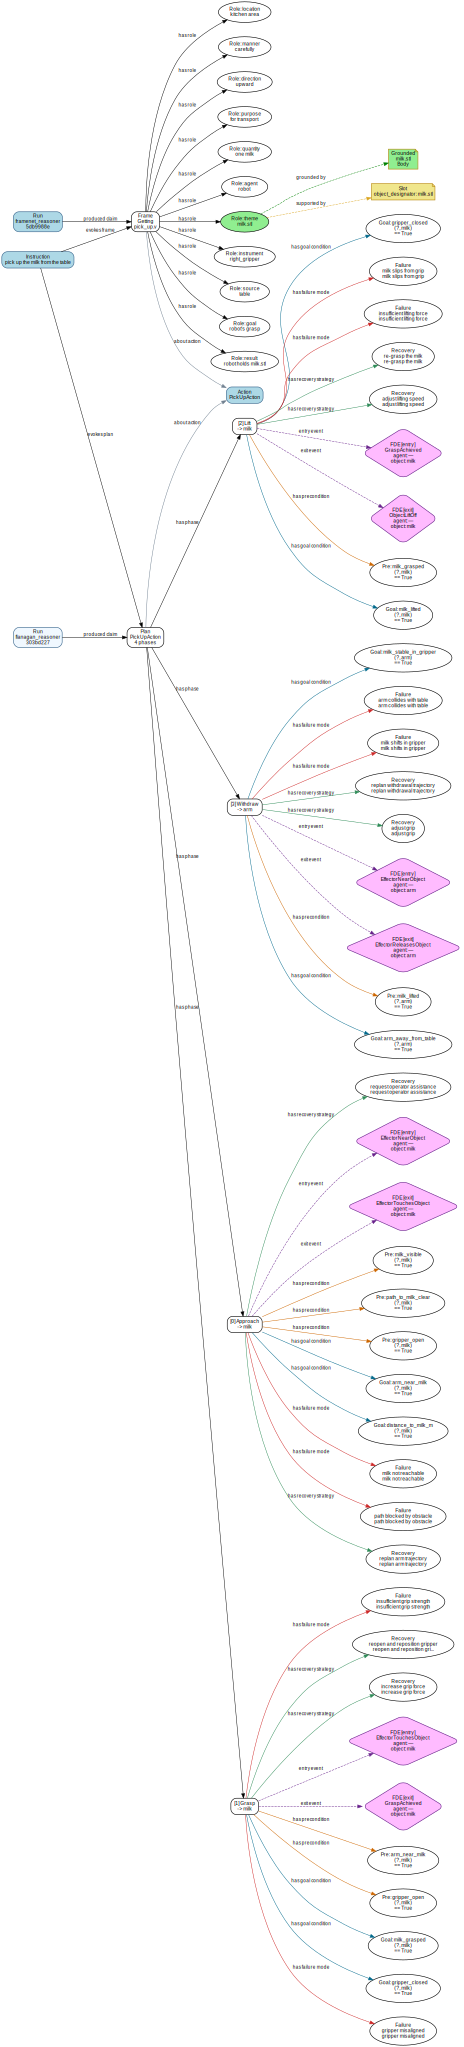

In [7]:
# Full hypothesis graph (both reasoners, both instructions)
# Full hypothesis graph (both reasoners, both instructions)
try:
    from graphviz import Source
    from IPython.display import display

    print("Full hypothesis graph (both reasoners):")
    display(Source(to_dot(graph), format="svg"))
except Exception as exc:
    print("Graphviz rendering unavailable:", exc)
    print(to_dot(graph))

In [ ]:
# Render the full graph; action1 entities can be identified via composition closure
action1_closure_entities = frame_closure(current_frame)
plan_closure = [current_plan] + current_plan.phases
action1_all = list({n.id: n for n in action1_closure_entities + plan_closure}.values())

try:
    from graphviz import Source
    from IPython.display import display

    print(f"composition closure(action1 frame): {len(action1_all)} entities")
    display(Source(to_dot(graph), format="svg"))
except Exception as exc:
    print("Graphviz rendering unavailable:", exc)
    print(to_dot(graph))

## Summary — API Reference

| API | Where | Use |
|---|---|---|
| `graph.domain(cls)` | `graph.py` | O(1) typed domain; MRO-aware |
| `graph.get_instances_of_type(cls)` | `graph.py` | KRROOD-compatible instance provider |
| `iter(graph)` / `for n in graph` | `graph.py` | all entities; enables `variable(T, domain=graph)` |
| `len(graph)` | `graph.py` | total entity count |
| `BuildOrchestrator.with_default_builders()` | `builders/base.py` | auto-wire all registered builders |
| `graph.claims_for_action(action_ref)` | `graph.py` | all claims for a specific action |
| `graph.nodes_for_run(run_id)` | `graph.py` | all nodes tagged with a run_id |
| `graph.nodes_from_reasoner(name)` | `graph.py` | all nodes from a reasoner by name |
| `frame.roles` | `entities/framenet.py` | FrameClaim → RoleClaim (composition) |
| `plan.phases` | `entities/flanagan.py` | PlanClaim → PhaseClaim (composition) |
| `role.frame` | `entities/framenet.py` | RoleClaim → FrameClaim (back-ref) |
| `phase.plan` | `entities/flanagan.py` | PhaseClaim → PlanClaim (back-ref) |
| `frame.action` | `entities/framenet.py` | FrameClaim → Action (back-ref) |
| `plan.action` | `entities/flanagan.py` | PlanClaim → Action (back-ref) |
| `frame.instruction` | `entities/framenet.py` | FrameClaim → Instruction (back-ref) |
| `plan.instruction` | `entities/flanagan.py` | PlanClaim → Instruction (back-ref) |
| `action.frame_claims` | `entities/common.py` | Action → FrameClaim list |
| `action.plan_claims` | `entities/common.py` | Action → PlanClaim list |
| `instruction.frames` | `entities/common.py` | Instruction → FrameClaim list |
| `instruction.plans` | `entities/common.py` | Instruction → PlanClaim list |
| `role.supported_by` | `entities/framenet.py` | RoleClaim → SlotEvidence list |
| `role.grounded_by` | `entities/framenet.py` | RoleClaim → GroundingEvidence list |
| `FlanaganGraphView(graph=graph)` | `views/flanagan.py` | typed query facade for Flanagan entities |
| `FrameNetGraphView(graph=graph)` | `views/framenet.py` | typed query facade for FrameNet entities |
| `to_dot(graph)` | `adapters/dot.py` | DOT export for visualization |